# Example for the modularized peakTree with RPG FMWC

using the lv0 binary format

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import xarray as xr

from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt

import numpy as np

import cmcrameri.cm as cmc

import sys
sys.path.append('../peakTree/')
import peakTree

In [3]:
%matplotlib inline

In [4]:
files = sorted(list(Path('/data/userdata/miratools/case_munich/FMCW94').glob('*LV0')))
files

[PosixPath('/data/userdata/miratools/case_munich/FMCW94/250909_000000_P08_ZEN.LV0'),
 PosixPath('/data/userdata/miratools/case_munich/FMCW94/250909_010000_P08_ZEN.LV0'),
 PosixPath('/data/userdata/miratools/case_munich/FMCW94/250909_020001_P08_ZEN.LV0'),
 PosixPath('/data/userdata/miratools/case_munich/FMCW94/250909_030003_P08_ZEN.LV0'),
 PosixPath('/data/userdata/miratools/case_munich/FMCW94/250909_040002_P08_ZEN.LV0'),
 PosixPath('/data/userdata/miratools/case_munich/FMCW94/250909_050003_P08_ZEN.LV0'),
 PosixPath('/data/userdata/miratools/case_munich/FMCW94/250909_060001_P08_ZEN.LV0'),
 PosixPath('/data/userdata/miratools/case_munich/FMCW94/250909_070002_P08_ZEN.LV0'),
 PosixPath('/data/userdata/miratools/case_munich/FMCW94/250909_080002_P08_ZEN.LV0'),
 PosixPath('/data/userdata/miratools/case_munich/FMCW94/250909_090000_P08_ZEN.LV0'),
 PosixPath('/data/userdata/miratools/case_munich/FMCW94/250909_100000_P08_ZEN.LV0'),
 PosixPath('/data/userdata/miratools/case_munich/FMCW94/250909_11

## RPG FMCW specific preprocessing

In contrast to the Mira files (dataset), the chirps are loaded as a datatree.

In [5]:
dt_input = peakTree.load_rpgbinary(files[13])

specslice slice(0, 512, None)
(883, 18, 512)
specslice slice(128, 384, None)


/home/miratools/peakTree_processing/dev_modularised/../peakTree/peakTree/__init__.py:208: RuntimeWarning: invalid value encountered in sqrt
  rhv = np.sqrt(spec_cov_re**2 + spec_cov_im**2) / np.sqrt(spec_v * spec_h)
/home/miratools/peakTree_processing/dev_modularised/../peakTree/peakTree/__init__.py:208: RuntimeWarning: invalid value encountered in divide
  rhv = np.sqrt(spec_cov_re**2 + spec_cov_im**2) / np.sqrt(spec_v * spec_h)


(883, 145, 256)
specslice slice(128, 384, None)
(883, 114, 256)


In [11]:
def resample_wrapper(ds, params):
    # Only resample if the node actually has the 'time' dimension
    if "time" in ds.dims:
        return ds.resample(time=params['resample_time']).mean()
    # If the node has no 'time' dim (or is empty), return it as-is
    return ds

tree_params = {'resample_time': "6s"}
# for this example a hard-coded resample time would work, but later this is more handy
#dt_input = dt_input.map_over_datasets(resample_wrapper)
dt_input = peakTree.map_over_dataset_nested_args(dt_input, resample_wrapper, tree_params) 

args  ({'resample_time': '6s'},)
nested args  [{'chirp1': {'resample_time': '6s'}, 'chirp2': {'resample_time': '6s'}, 'chirp3': {'resample_time': '6s'}}]


Text(0, 0.5, 'Range [m]')

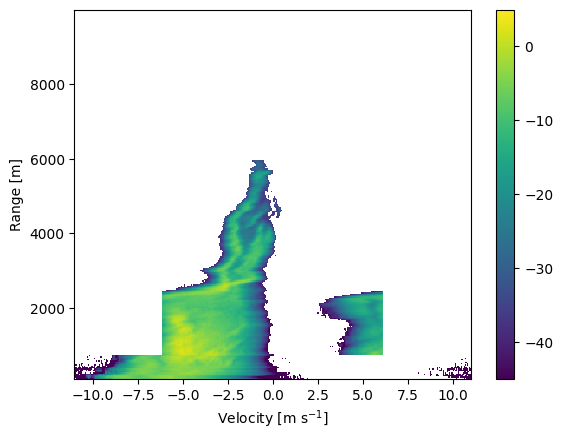

In [21]:
dt_spectrogramm = dt_input.isel(time=4)

fig, ax = plt.subplots()

for path, node in dt_spectrogramm.subtree_with_keys:
    if not node.has_data:
        continue

    pcmesh = ax.pcolormesh(
        node.doppler, node.range, 10*np.log10(node['Z']),
        vmin=-45, vmax=5,
    )

fig.colorbar(pcmesh)
#ax.set_ylim(0,3000)
ax.set_xlabel('Velocity [m s$^{-1}$]')
ax.set_ylabel('Range [m]')

In [ ]:
# the roll velocity can also be defined per chirp
# alternatively more sophisticated unfolding operations could also be used
dt_input = peakTree.map_over_dataset_nested_args(dt_input, peakTree.roll_velocity_dataset, {'roll_velocity': 4}) 

args  ({'roll_velocity': 4},)
nested args  [{'chirp1': {'roll_velocity': 4}, 'chirp2': {'roll_velocity': 4}, 'chirp3': {'roll_velocity': 4}}]
92 3.965596482157707
83 3.992190409451723
100 3.975170850753784


/home/miratools/peakTree_processing/p312-peaktree/lib/python3.12/site-packages/xarray/computation/apply_ufunc.py:820: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


Text(0, 0.5, 'Range [m]')

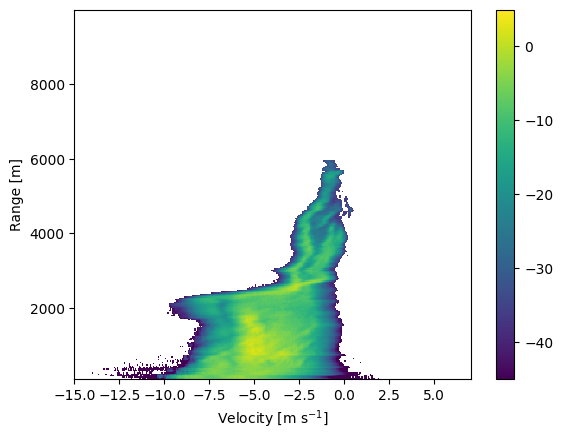

In [23]:

dt_spectrogramm = dt_input.isel(time=4)

fig, ax = plt.subplots()

for path, node in dt_spectrogramm.subtree_with_keys:
    if not node.has_data:
        continue

    pcmesh = ax.pcolormesh(
        node.doppler, node.range, 10*np.log10(node['Z']),
        vmin=-45, vmax=5,
    )

fig.colorbar(pcmesh)
#ax.set_ylim(0,3000)
ax.set_xlabel('Velocity [m s$^{-1}$]')
ax.set_ylabel('Range [m]')

In [24]:

def noise_thresholding(ds, config):
    if not ds:
        return None
    ds = ds.copy()
    ds['noise_mask'] = ds['Z'] < ds['noise']*config['Q']
    return ds

dt_input = peakTree.map_over_dataset_nested_args(dt_input, noise_thresholding, {'Q': 1.3})

args  ({'Q': 1.3},)
nested args  [{'chirp1': {'Q': 1.3}, 'chirp2': {'Q': 1.3}, 'chirp3': {'Q': 1.3}}]


## Convert to tree structure

In [ ]:
meta={
    'Z': ['M0', 'M1', 'M2', 'M3', 'P'],
    'Zcx': ['M0', 'P'],
    }


dt_rect = peakTree.to_tree(
    dt_input,
    {'width_thres': 0.1, 'prom_thres': 1},
    meta
)

args  ({'width_thres': 0.1, 'prom_thres': 1}, {'Z': ['M0', 'M1', 'M2', 'M3', 'P'], 'Zcx': ['M0', 'P']})
nested args  [{'chirp1': {'width_thres': 0.1, 'prom_thres': 1}, 'chirp2': {'width_thres': 0.1, 'prom_thres': 1}, 'chirp3': {'width_thres': 0.1, 'prom_thres': 1}}, {'chirp1': {'Z': ['M0', 'M1', 'M2', 'M3', 'P'], 'Zcx': ['M0', 'P']}, 'chirp2': {'Z': ['M0', 'M1', 'M2', 'M3', 'P'], 'Zcx': ['M0', 'P']}, 'chirp3': {'Z': ['M0', 'M1', 'M2', 'M3', 'P'], 'Zcx': ['M0', 'P']}}]


/home/miratools/peakTree_processing/dev_modularised/../peakTree/peakTree/generate_tree.py:170: RuntimeWarning: divide by zero encountered in scalar divide
  prom_left = spec_left[np.nanargmax(spec_left)]/current_thres
/home/miratools/peakTree_processing/dev_modularised/../peakTree/peakTree/generate_tree.py:173: RuntimeWarning: divide by zero encountered in scalar divide
  prom_right = spec_right[np.nanargmax(spec_right)]/current_thres
/home/miratools/peakTree_processing/dev_modularised/../peakTree/peakTree/generate_tree.py:445: RuntimeWarning: divide by zero encountered in scalar divide
  mom['P'] = Z_chunk[ind_max] / thres
/home/miratools/peakTree_processing/dev_modularised/../peakTree/peakTree/generate_tree.py:170: RuntimeWarning: divide by zero encountered in scalar divide
  prom_left = spec_left[np.nanargmax(spec_left)]/current_thres
/home/miratools/peakTree_processing/dev_modularised/../peakTree/peakTree/generate_tree.py:173: RuntimeWarning: divide by zero encountered in scalar di

## Post-processing and storage

For convenience the single chirps can now be combined into a single dataset

In [30]:
combined_ds = xr.concat([dt_rect[child].to_dataset() for child in dt_rect.keys()], dim='range')

/tmp/ipykernel_511915/1927483333.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  combined_ds = xr.concat([dt_rect[child].to_dataset() for child in dt_rect.keys()], dim='range')


In [38]:
combined_ds

<xarray.Dataset> Size: 216MB
Dimensions:         (time: 600, range: 277, node: 15)
Coordinates:
  * time            (time) datetime64[s] 5kB 2025-09-09T13:00:00 ... 2025-09-...
  * range           (range) float64 2kB 107.3 143.1 ... 9.945e+03 9.981e+03
Dimensions without coordinates: node
Data variables: (12/17)
    bounds_left     (time, range, node) int32 10MB 125 125 138 ... -999 -999
    bounds_right    (time, range, node) int32 10MB 370 138 370 ... -999 -999
    id_parent       (time, range, node) int32 10MB -1 0 0 ... -999 -999 -999
    thres           (time, range, node) float64 20MB 2.34e-06 ... -999.0
    Z_M0            (time, range, node) float64 20MB 37.32 0.0184 ... -999.0
    Z_M1            (time, range, node) float64 20MB -4.852 -9.145 ... -999.0
    ...              ...
    no_nodes        (time, range) int64 1MB 7 5 5 7 1 7 7 7 ... 0 0 0 0 0 0 0 0
    id_child_left   (range, node) int64 33kB 1 3 5 7 9 11 ... 19 21 23 25 27 29
    id_child_right  (range, node) int64 33kB 2 4 6 8 10 12 ... 20 22 24 26 28 30
    has_children    (time, range, node) bool 2MB True False True ... False False
    is_leaf         (time, range, node) bool 2MB False True ... False False
    LDR             (time, range, node) float64 20MB 0.001378 -999.0 ... -999.0

In [31]:

combined_ds['LDR'] = xr.where(
    combined_ds['Zcx_M0'] < 10**(-40/10), -999, combined_ds['Zcx_M0'] / combined_ds['Z_M0'])

In [33]:

dt = combined_ds.time.values[0].astype('datetime64[us]').astype('O')
combined_ds.to_netcdf(
    path=f'{dt:%Y%m%d_%H%M}_rpgfmcw94_peakTree.nc4'
)
# or the function with enriched metadata
# peakTree.store_to_netcdf(ds_rect, '', system_name='rpgfmcw94')

## Plotting

(0.0, 9000.0)

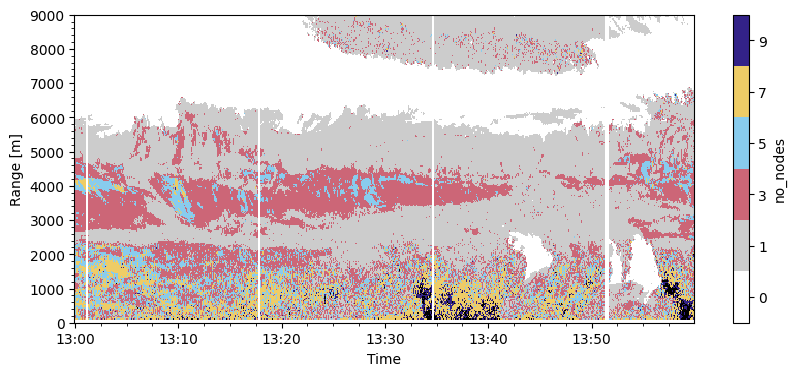

In [35]:
fig, ax = peakTree.print_tree.plot_no_nodes(combined_ds)

ax.set_ylim(0, 9000)

/home/miratools/peakTree_processing/dev_modularised/../peakTree/peakTree/print_tree.py:341: UserWarning: The following kwargs were not used by contour: 'shading'
  cf = ax[i,0].contourf(
/home/miratools/peakTree_processing/dev_modularised/../peakTree/peakTree/print_tree.py:360: UserWarning: The following kwargs were not used by contour: 'shading'
  cf = ax[i,1].contourf(


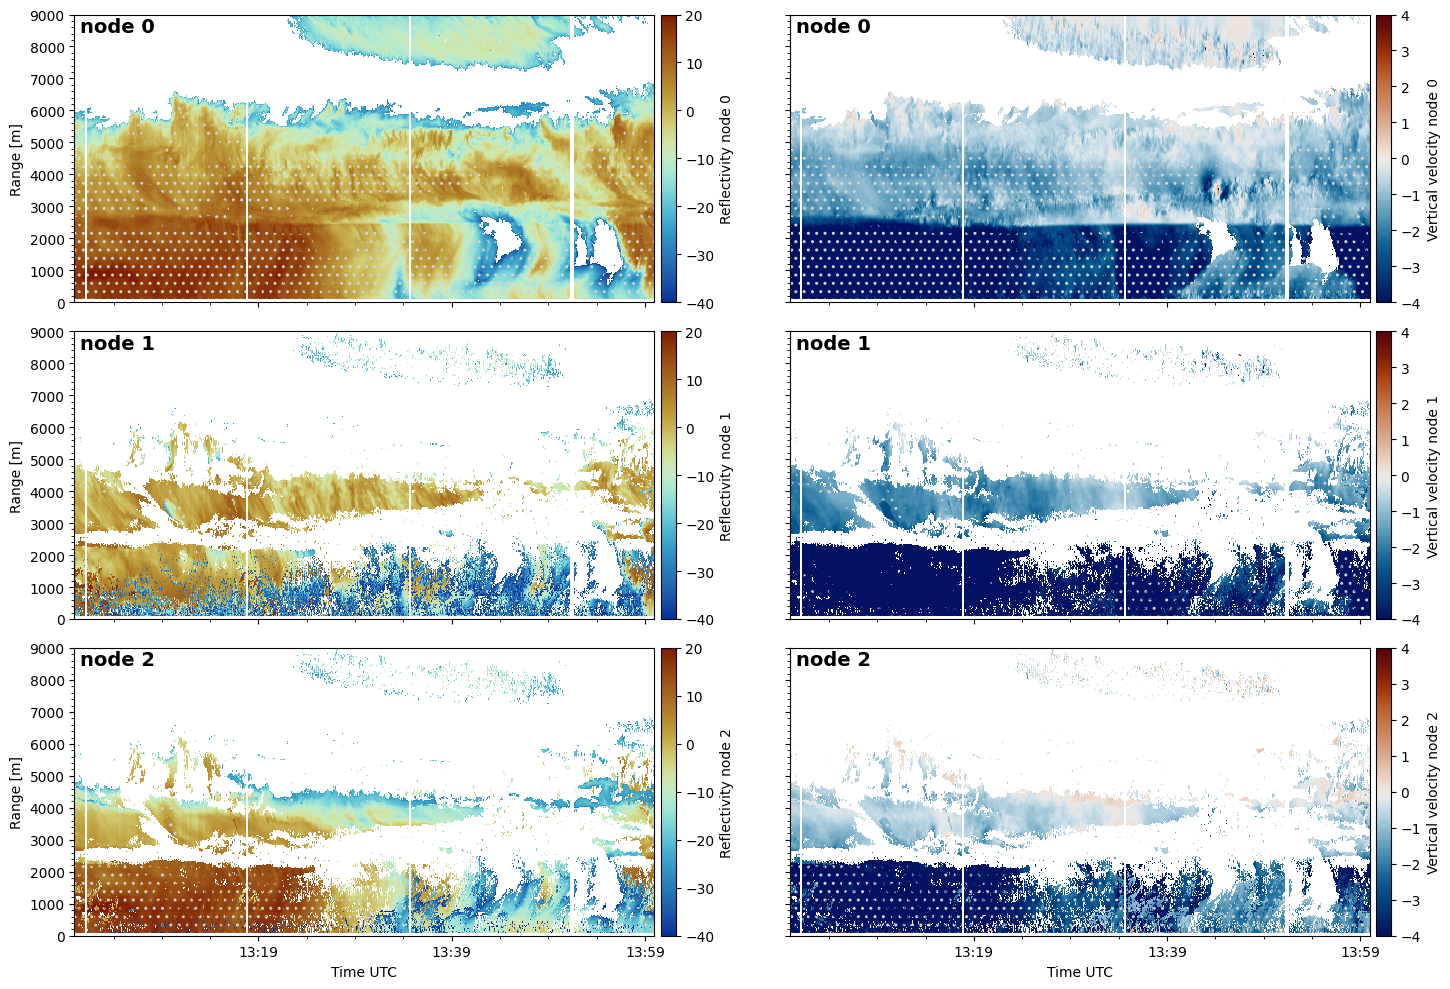

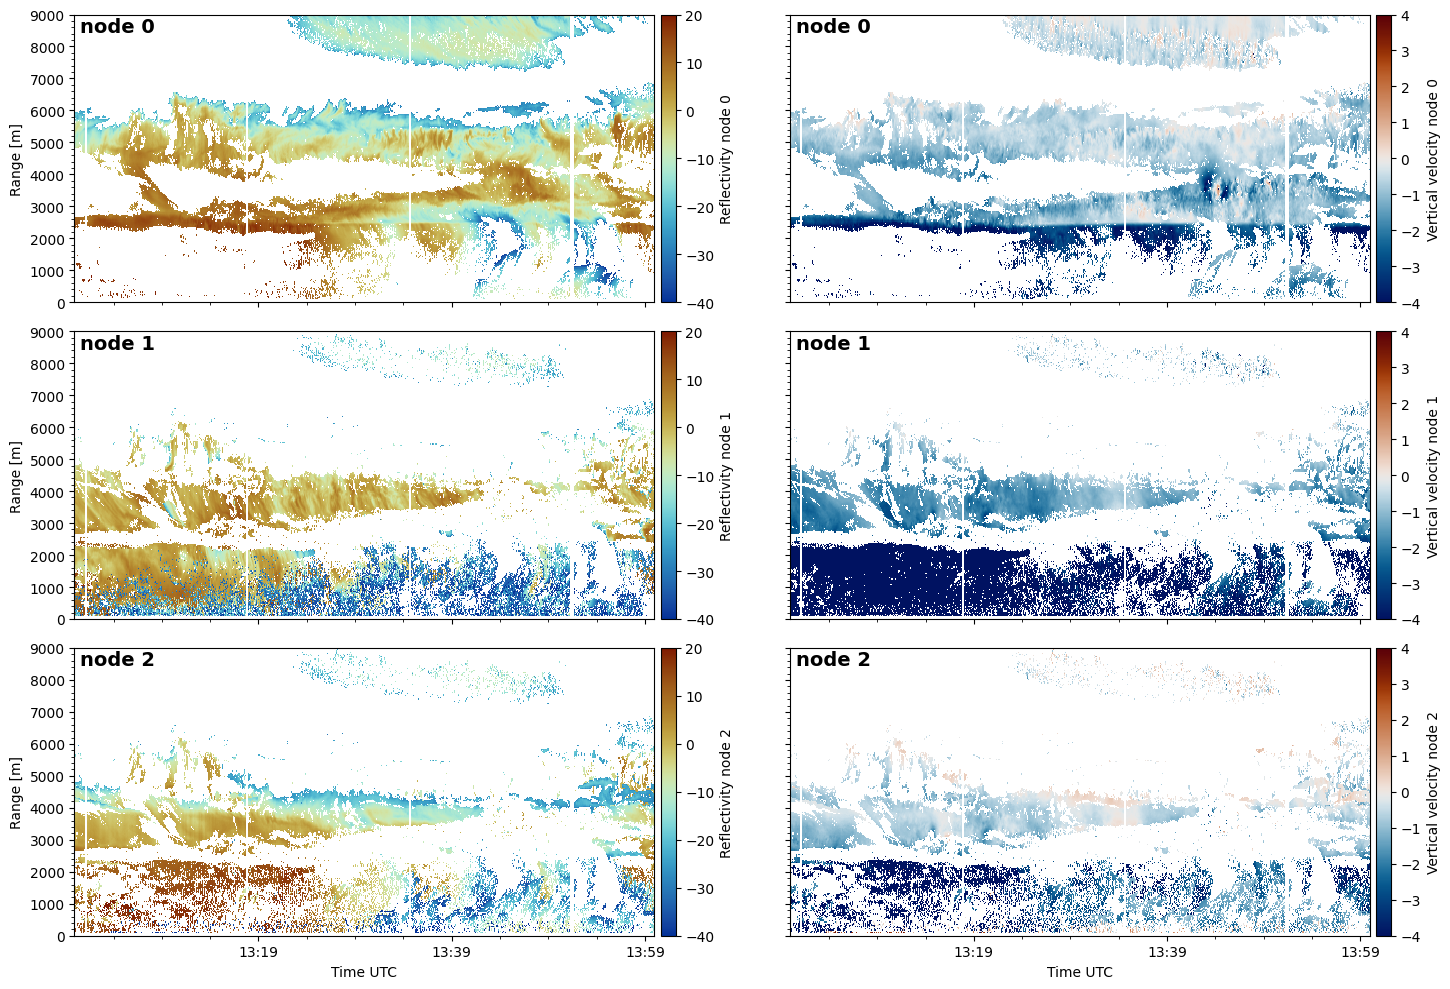

In [37]:
fig, ax = peakTree.print_tree.plot_moments(combined_ds, mark_has_children=True)
ax[0,0].set_ylim(0,9000)
ax[0,0].xaxis.set_major_locator(matplotlib.dates.MinuteLocator(interval=20))
ax[0,1].xaxis.set_major_locator(matplotlib.dates.MinuteLocator(interval=20))


fig, ax = peakTree.print_tree.plot_moments(combined_ds, mask_not_leaf=True)
ax[0,0].set_ylim(0,9000)

ax[0,0].xaxis.set_major_locator(matplotlib.dates.MinuteLocator(interval=20))
ax[0,1].xaxis.set_major_locator(matplotlib.dates.MinuteLocator(interval=20))